In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as mt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import mlxtend
from mlxtend.plotting import plot_decision_regions
import pickle
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import cross_val_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import auc
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier




In [71]:
df = pd.read_csv('college_student_placement_dataset.csv')

In [72]:
df.head()

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No
2,CLG0036,109,5.36,5.83,9,No,3,1,1,No
3,CLG0055,122,5.47,5.75,6,Yes,1,6,1,No
4,CLG0004,96,7.91,7.69,7,No,8,10,2,No


In [73]:
df= df.iloc[:,1:]

In [74]:
df.head()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,107,6.61,6.28,8,No,8,8,4,No
1,97,5.52,5.37,8,No,7,8,0,No
2,109,5.36,5.83,9,No,3,1,1,No
3,122,5.47,5.75,6,Yes,1,6,1,No
4,96,7.91,7.69,7,No,8,10,2,No


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   IQ                      10000 non-null  int64  
 1   Prev_Sem_Result         10000 non-null  float64
 2   CGPA                    10000 non-null  float64
 3   Academic_Performance    10000 non-null  int64  
 4   Internship_Experience   10000 non-null  str    
 5   Extra_Curricular_Score  10000 non-null  int64  
 6   Communication_Skills    10000 non-null  int64  
 7   Projects_Completed      10000 non-null  int64  
 8   Placement               10000 non-null  str    
dtypes: float64(2), int64(5), str(2)
memory usage: 747.8 KB


In [76]:
# Convert columns
df["Internship_Experience"] = df["Internship_Experience"].map({
    "Yes": 1,
    "No": 0
})

df["Placement"] = df["Placement"].map({
    "Yes": 1,
    "No": 0
})

print(df.head())

    IQ  Prev_Sem_Result  CGPA  Academic_Performance  Internship_Experience  \
0  107             6.61  6.28                     8                      0   
1   97             5.52  5.37                     8                      0   
2  109             5.36  5.83                     9                      0   
3  122             5.47  5.75                     6                      1   
4   96             7.91  7.69                     7                      0   

   Extra_Curricular_Score  Communication_Skills  Projects_Completed  Placement  
0                       8                     8                   4          0  
1                       7                     8                   0          0  
2                       3                     1                   1          0  
3                       1                     6                   1          0  
4                       8                    10                   2          0  


In [77]:
print(df.columns)

Index(['IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='str')


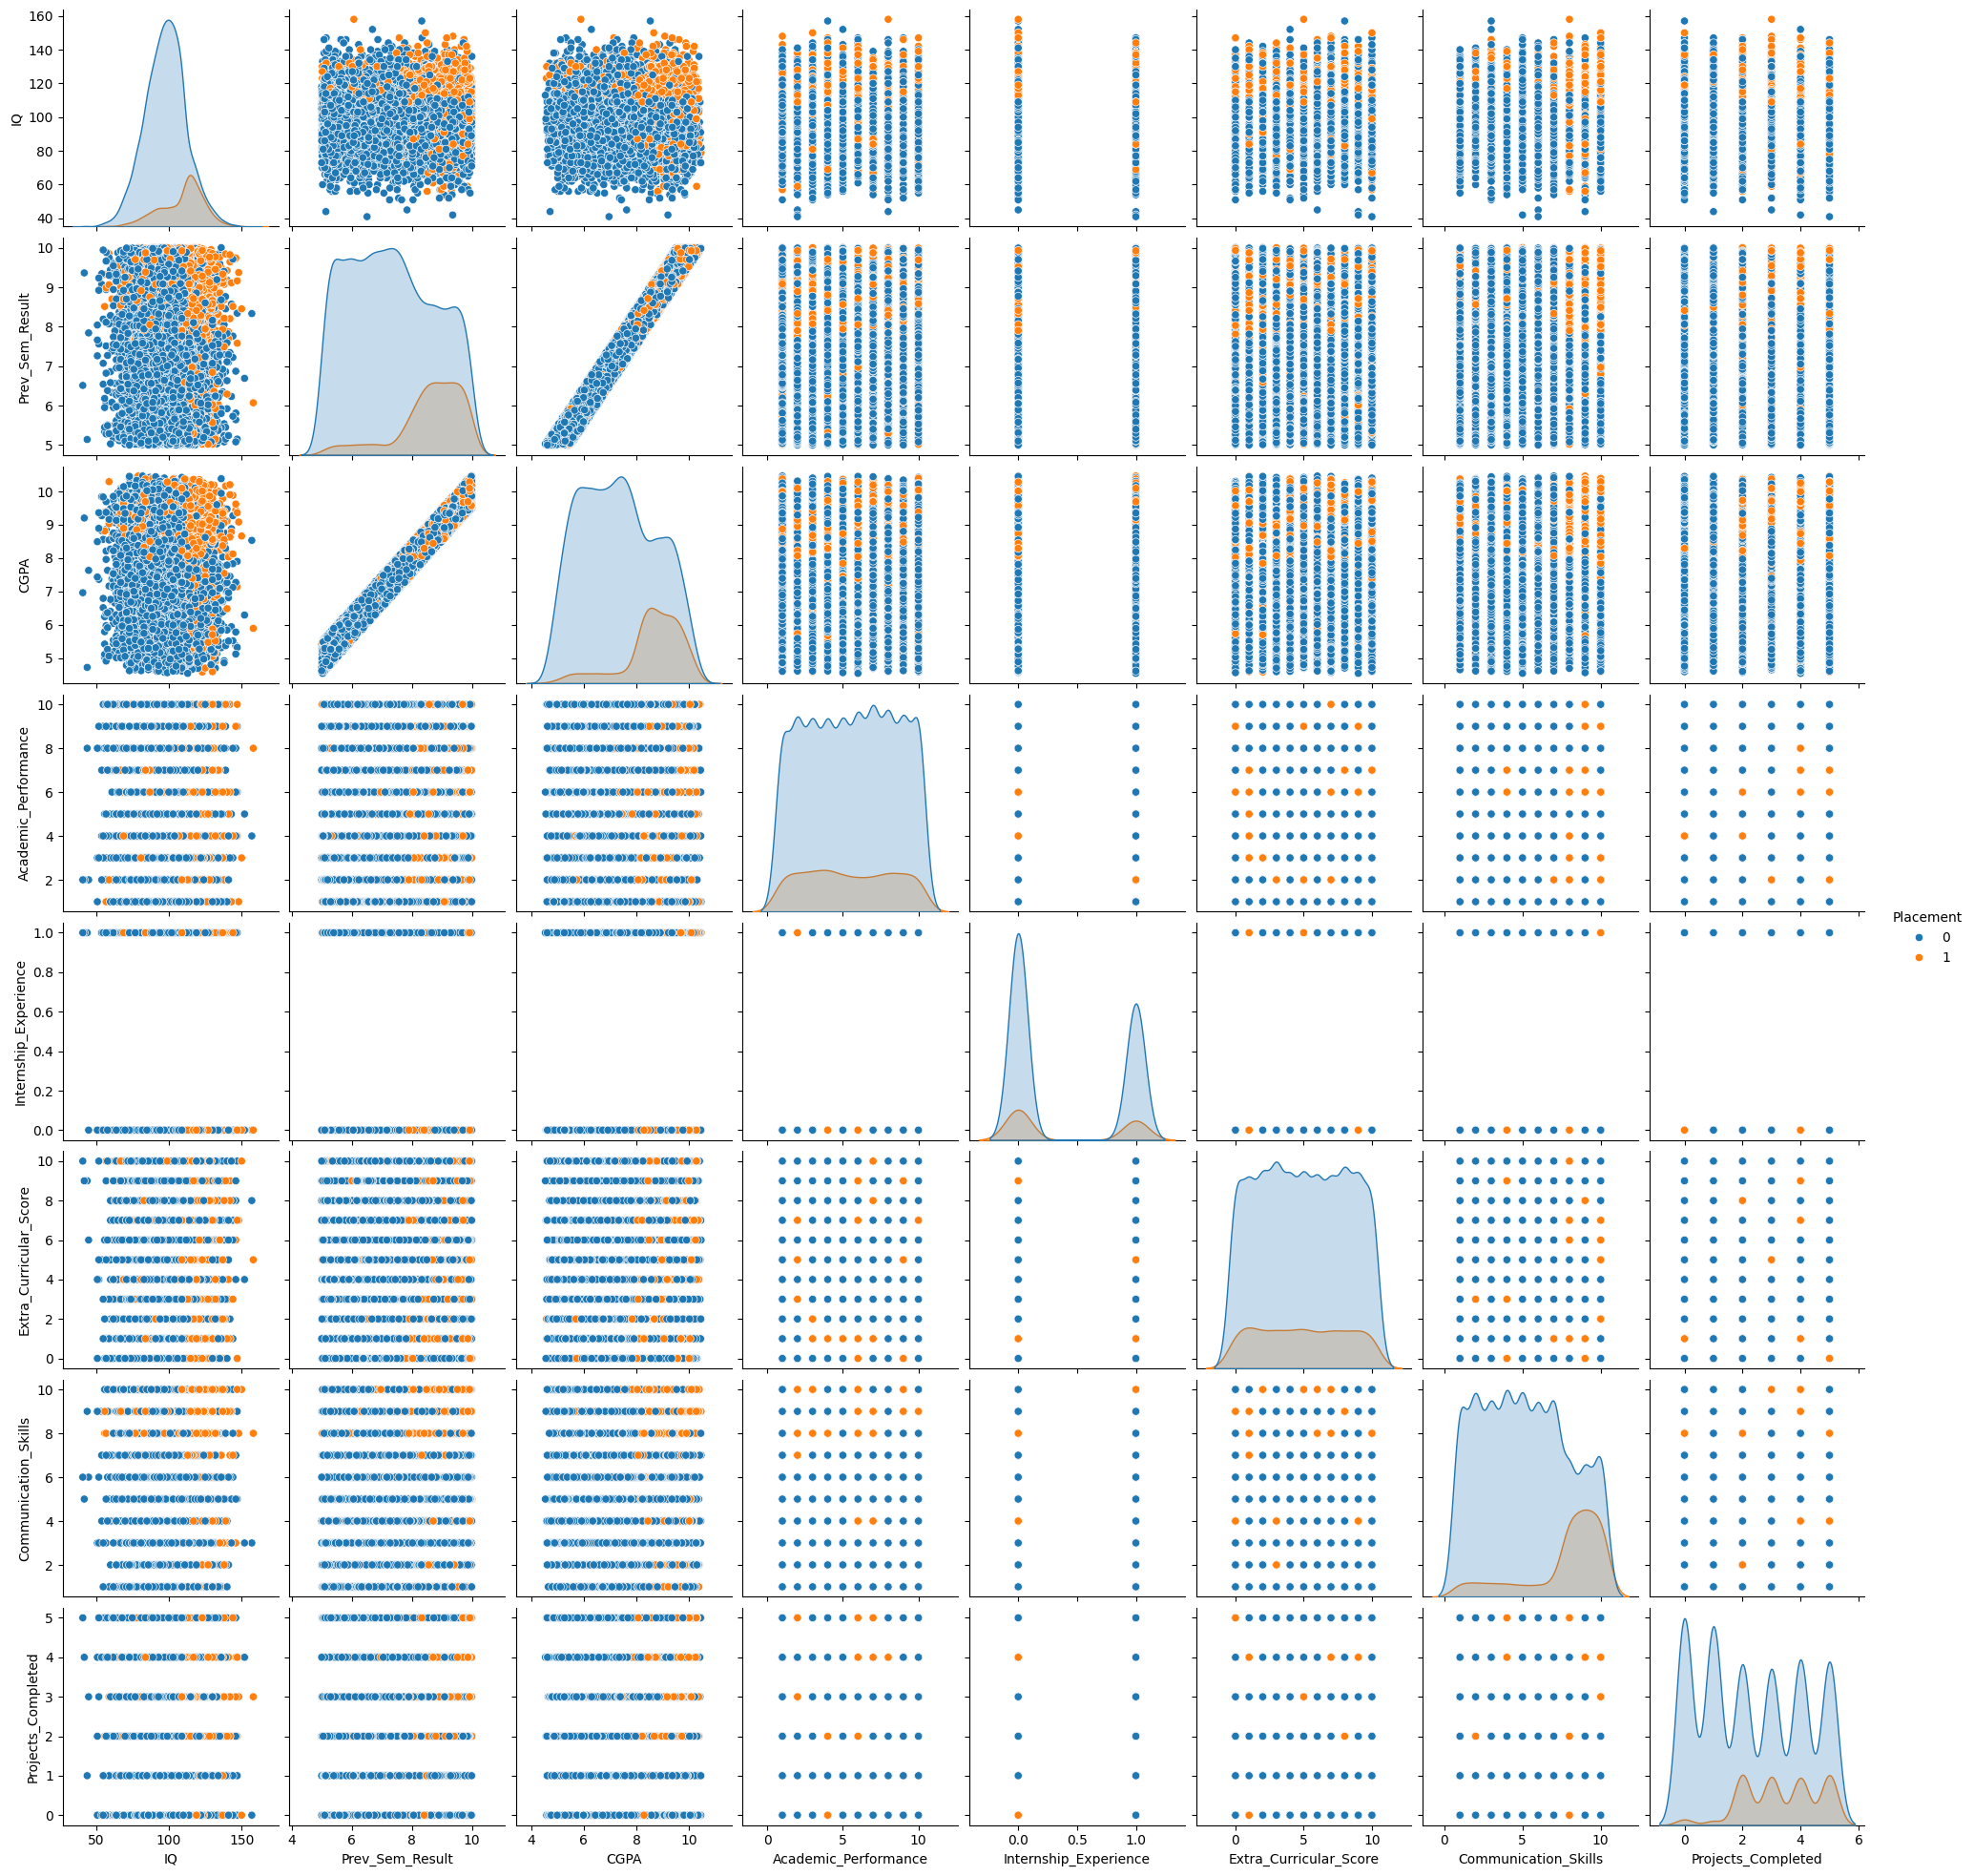

In [78]:
import seaborn as sns
import matplotlib.pyplot as mt

columns = [
    'IQ',
    'Prev_Sem_Result',
    'CGPA',
    'Academic_Performance',
    'Internship_Experience',
    'Extra_Curricular_Score',
    'Communication_Skills',
    'Projects_Completed',
    'Placement'
]

sns.pairplot(
    df[columns],
    hue='Placement'
)

mt.show()

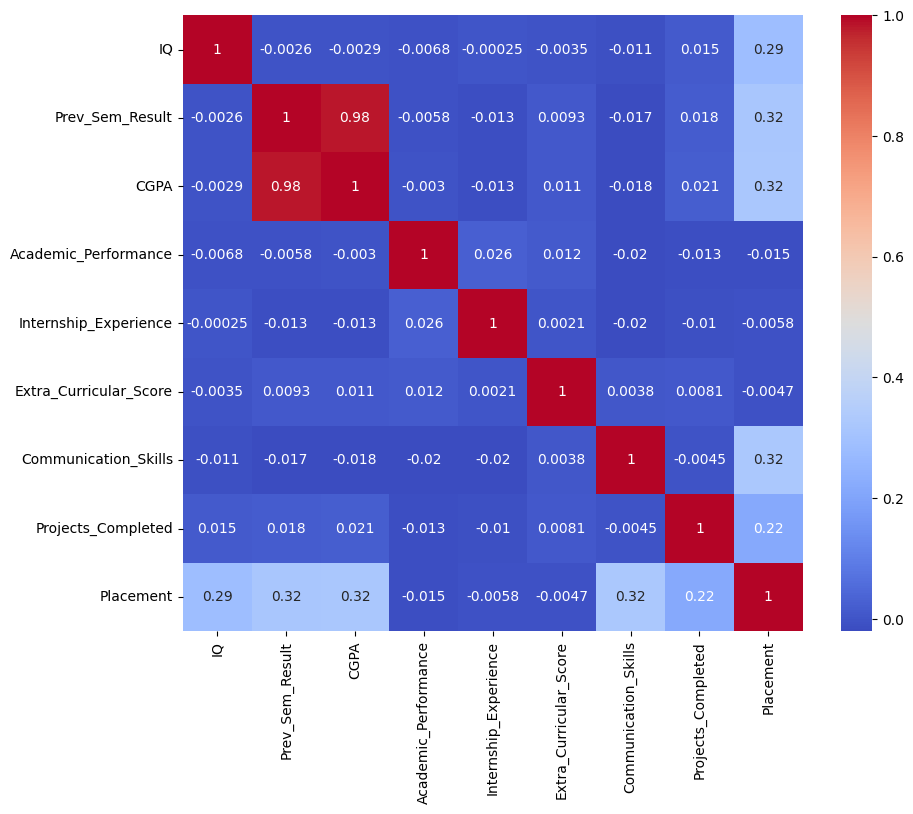

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [80]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

X = df.drop('Placement', axis=1)
y = df['Placement']

model.fit(X, y)

importance = model.feature_importances_

for i,v in enumerate(importance):
    print(X.columns[i], v)

IQ 0.2665491101647047
Prev_Sem_Result 0.10500615371624629
CGPA 0.15754453953546022
Academic_Performance 0.009449367736780075
Internship_Experience 0.0026541292793811956
Extra_Curricular_Score 0.010740374835811119
Communication_Skills 0.28790666039647184
Projects_Completed 0.16014966433514466


In [81]:
# Keep only important features

important_features = [
    'IQ',
    'CGPA',
    'Communication_Skills',
    'Projects_Completed',
    'Placement'
]

# Create cleaned dataset
df_cleaned = df[important_features]

# Check columns
print(df_cleaned.columns)

# Save cleaned dataset
df_cleaned.to_csv("cleaned_dataset.csv", index=False)

print("Cleaned dataset saved successfully!")

Index(['IQ', 'CGPA', 'Communication_Skills', 'Projects_Completed',
       'Placement'],
      dtype='str')
Cleaned dataset saved successfully!


In [82]:
df_cleaned

,IQ,CGPA,Communication_Skills,Projects_Completed,Placement
0,107,6.28,8,4,0
1,97,5.37,8,0,0
2,109,5.83,1,1,0
3,122,5.75,6,1,0
4,96,7.69,10,2,0
...,...,...,...,...,...
9995,119,8.29,8,0,1
9996,70,9.34,7,2,0
9997,89,6.25,9,5,0
9998,107,8.92,5,1,0


In [83]:
indep = df_cleaned.iloc[:,0:4]
dep = df_cleaned.iloc[:,-1]

In [84]:
indep

,IQ,CGPA,Communication_Skills,Projects_Completed
0,107,6.28,8,4
1,97,5.37,8,0
2,109,5.83,1,1
3,122,5.75,6,1
4,96,7.69,10,2
...,...,...,...,...
9995,119,8.29,8,0
9996,70,9.34,7,2
9997,89,6.25,9,5
9998,107,8.92,5,1


In [85]:
dep

0       0
1       0
2       0
3       0
4       0
       ..
9995    1
9996    0
9997    0
9998    0
9999    0
Name: Placement, Length: 10000, dtype: int64

In [86]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(indep,dep,test_size=0.3, random_state= 42)

In [87]:
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.fit_transform(Xtest)
Xtrain
Xtest

array([[ 2.64099843, -0.19330704, -0.55645591,  0.87967993],
       [-1.00853082,  0.66462534, -0.90380666,  1.46263548],
       [-0.34498005, -1.27773356,  1.52764862,  0.87967993],
       ...,
       [-0.4776902 ,  1.04897905,  1.52764862,  0.29672438],
       [-1.40666128, -0.8178818 ,  0.83294711,  1.46263548],
       [-0.07955974,  0.54108308,  0.83294711, -0.28623118]],
      shape=(3000, 4))

In [88]:
models = {

    "Logistic Regression":
    LogisticRegression(
        class_weight='balanced',
        C=0.1,
        max_iter=1000
    ),

    "Random Forest":
    RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        min_samples_split=10,
        min_samples_leaf=5,
        class_weight='balanced',
        random_state=42
    ),

    "SVM":
    SVC(
        class_weight='balanced'
    ),

    "KNN":
    KNeighborsClassifier(
        n_neighbors=7
    )

}

best_model = None
best_model_name = ""
best_f1 = 0

for name, model in models.items():

    print("\n")
    print("===================================================")
    print("MODEL :", name)
    print("===================================================")

    model.fit(Xtrain, Ytrain)

    pred = model.predict(Xtest)

    accuracy = accuracy_score(Ytest, pred)

    precision = precision_score(Ytest, pred)

    recall = recall_score(Ytest, pred)

    f1 = f1_score(Ytest, pred)

    cv_scores = cross_val_score(
        model,
        Xtrain,
        Ytrain,
        cv=5,
        scoring='f1'
    )

    print("\nAccuracy :")
    print(round(accuracy, 4))

    print("\nPrecision :")
    print(round(precision, 4))

    print("\nRecall :")
    print(round(recall, 4))

    print("\nF1 Score :")
    print(round(f1, 4))

    print("\nCross Validation F1 Scores :")
    print(cv_scores)

    print("\nAverage CV F1 Score :")
    print(round(cv_scores.mean(), 4))

    print("\nConfusion Matrix :")
    print(confusion_matrix(Ytest, pred))

    print("\nClassification Report :")
    print(classification_report(Ytest, pred))

    if f1 > best_f1:

        best_f1 = f1

        best_model = model

        best_model_name = name

print("\n")
print("===================================================")
print("BEST MODEL :", best_model_name)
print("BEST F1 SCORE :", round(best_f1, 4))
print("===================================================")


best_model.fit(Xtrain, Ytrain)




MODEL : Logistic Regression

Accuracy :
0.8497

Precision :
0.5231

Recall :
0.8814

F1 Score :
0.6565

Cross Validation F1 Scores :
[0.65346535 0.65732087 0.65700483 0.66666667 0.68092105]

Average CV F1 Score :
0.6631

Confusion Matrix :
[[2118  393]
 [  58  431]]

Classification Report :
              precision    recall  f1-score   support

           0       0.97      0.84      0.90      2511
           1       0.52      0.88      0.66       489

    accuracy                           0.85      3000
   macro avg       0.75      0.86      0.78      3000
weighted avg       0.90      0.85      0.86      3000



MODEL : Random Forest

Accuracy :
0.9993

Precision :
0.9959

Recall :
1.0

F1 Score :
0.998

Cross Validation F1 Scores :
[0.99785867 1.         1.         1.         1.        ]

Average CV F1 Score :
0.9996

Confusion Matrix :
[[2509    2]
 [   0  489]]

Classification Report :
              precision    recall  f1-score   support

           0       1.00      1.00      1

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [89]:

roc = roc_auc_score(Ytest, pred)

print("ROC AUC:", roc)

ROC AUC: 0.9790333575213845


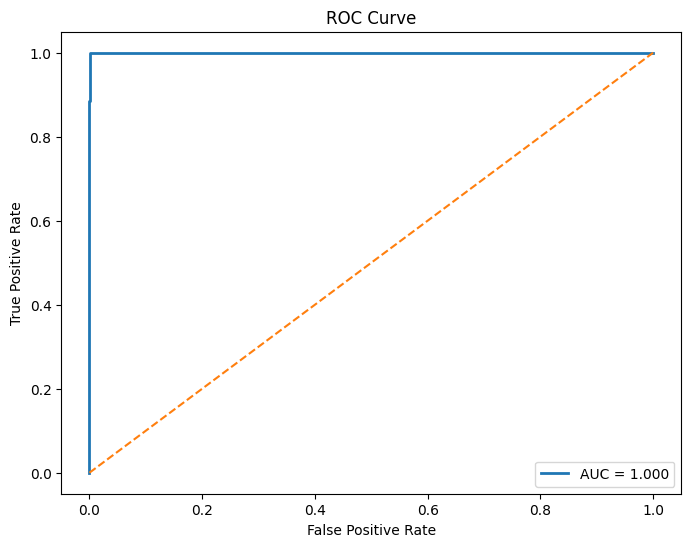

In [90]:
# Get probability predictions
y_prob = best_model.predict_proba(Xtest)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(Ytest, y_prob)

# Calculate AUC score
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f'AUC = {roc_auc:.3f}'
)

# Random baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle='--'
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend(loc="lower right")

plt.show()

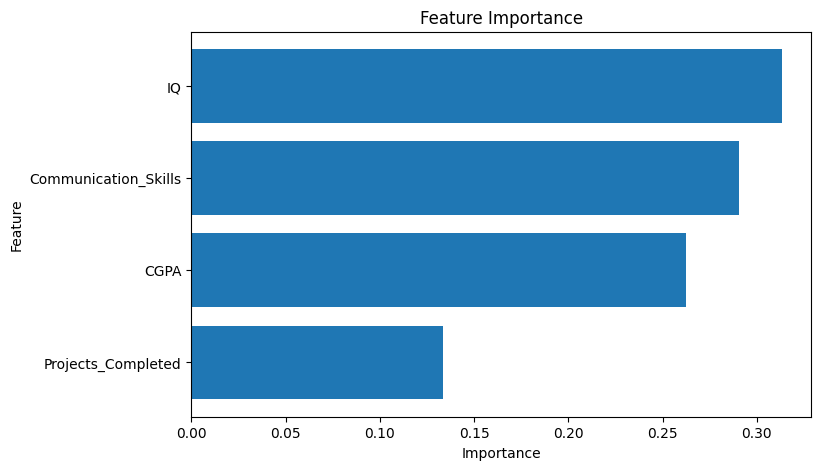

In [91]:

importance = best_model.feature_importances_

feature_names = [
    'IQ',
    'CGPA',
    'Communication_Skills',
    'Projects_Completed'
]

imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

imp_df = imp_df.sort_values(by='Importance')

plt.figure(figsize=(8,5))

plt.barh(imp_df['Feature'], imp_df['Importance'])

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.title("Feature Importance")

plt.show()

In [92]:
# Predict on test data
y_pred = best_model.predict(Xtest)

# Print predictions
print(y_pred)

[0 0 0 ... 1 0 1]


In [93]:
import pandas as pd

comparison = pd.DataFrame({

    'Actual': Ytest,
    'Predicted': y_pred

})

print(comparison.head(20))

      Actual  Predicted
6252       0          0
4684       0          0
1731       0          0
4742       0          0
4521       1          1
6340       0          0
576        1          1
5202       0          0
6363       0          0
439        0          0
2750       0          0
7487       0          0
5272       0          0
5653       1          1
3999       1          1
6033       0          0
582        0          0
9930       0          0
7051       0          0
8158       0          0


In [94]:


accuracy = accuracy_score(Ytest, y_pred)

print("Accuracy :", accuracy)

Accuracy : 0.9993333333333333


In [95]:
new_student = [[
    120,   # IQ
    8.5,   # CGPA
    9,     # Communication Skills
    4      # Projects Completed
]]

In [96]:
# Scale new data
new_student_scaled = scaler.transform(new_student)

# Get probabilities
probability = best_model.predict_proba(
    new_student_scaled
)

# Placement probability
placed_probability = probability[0][1]

# Custom threshold
threshold = 0.65

# Final prediction
if placed_probability >= threshold:
    prediction = 1
else:
    prediction = 0

# Output
if prediction == 1:

    print("Student is likely to be PLACED")

else:

    print("Student is likely to be NOT PLACED")

# Print probability
print(
    f"Placement Probability: {placed_probability*100:.2f}%"
)

Student is likely to be PLACED
Placement Probability: 100.00%


c:\Users\703457001\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [97]:
probability = best_model.predict_proba(
    new_student_scaled
)

print(probability)

[[0. 1.]]


In [98]:
placed_probability = probability[0][1] * 100

print(
    f"Placement Probability: {placed_probability:.2f}%"
)

Placement Probability: 100.00%


In [99]:
import joblib

joblib.dump(best_model, "placement_model.pkl")

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [100]:
# =========================================
# IMPORTS
# =========================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

import joblib

# =========================================
# CREATE MODELS
# =========================================

logistic_model = LogisticRegression(
    max_iter=1000
)

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

svm_model = SVC(
    probability=True
)

# =========================================
# TRAIN MODELS
# =========================================

logistic_model.fit(Xtrain, Ytrain)

random_forest_model.fit(Xtrain, Ytrain)

svm_model.fit(Xtrain, Ytrain)

# =========================================
# SAVE MODELS
# =========================================

joblib.dump(
    logistic_model,
    "logistic.pkl"
)

joblib.dump(
    random_forest_model,
    "rf.pkl"
)

joblib.dump(
    svm_model,
    "svm.pkl"
)

print("All models saved successfully.")

All models saved successfully.


In [101]:
# Model
rf = RandomForestClassifier()

# Parameters
params = {

    'n_estimators': [100, 200],

    'max_depth': [5, 10, 15],

    'min_samples_split': [2, 5, 10]

}

# Grid Search
grid = GridSearchCV(

    rf,

    params,

    cv=5,

    scoring='f1',

    verbose=2,

    n_jobs=-1

)

# Train
grid.fit(Xtrain, Ytrain)

# Best Parameters
print(grid.best_params_)

# Best Score
print(grid.best_score_)

# Best Model
best_model = grid.best_estimator_

Fitting 5 folds for each of 18 candidates, totalling 90 fits
{'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 100}
1.0
